Note: this notebok is used to prepare the dataset for the model training and to be used in project, since the dataset is very large and contains almost 1M rows across different categories i.e., primary, social, promotion, updates, spam and phishing but we only need four categories that are spam, promotion, social and important so we would remove other categories and made some other changes that are follows:
1. The dataset contains 20 columns and we need 2 columns that is email and label so we will remove other columns.
2. we will remove all the missing values.
3. we will also remove the duplictates values.
4. we will also remove those rows having less char and words after preprocessing.
5. we will also check the data and remove unwanted values etc so that our data should be clean and our model can train easily.

Dataset_link: https://www.kaggle.com/datasets/sharmajicoder/email-spam-classification

This is the dataset link you can download it and run the model since the dataset is over 250MB and github doesnt allows us to upload a dataset having more then 100MB, so you can download this dataset from the following link.


In [1]:
# import the required libraries
import numpy as np
import pandas as pd

In [9]:
# load the dataset
data = pd.read_csv('new.csv')

In [10]:
data.head()

,email_id,sender_email,sender_domain,subject,body,num_links,num_attachments,has_urgent_words,has_spam_words,has_phishing_words,contains_html,email_length,num_exclamations,num_uppercase_words,day_of_week,hour,is_reply,is_forward,sender_reputation,label
0,1,julie36@company.com,company.com,Limited time offer!,Follow attention anything support market diffe...,3,0,0,1,0,1,144,0,0,3,4,0,1,0.38,spam
1,2,barberhenry@gmail.com,gmail.com,You won $$$,Experience back public event address without t...,1,1,0,1,0,0,219,0,0,4,8,1,1,0.20,spam
2,3,johnsonshelby@yahoo.com,yahoo.com,Your order has shipped,Treat recently happy pretty color statement. A...,0,0,0,0,0,0,287,0,0,3,22,0,1,0.21,updates
3,4,awebb@bank.com,bank.com,Account update notification,Onto always strategy training. Skill our disco...,1,0,0,0,0,0,256,0,0,5,23,0,0,0.72,updates
4,5,xmyers@company.com,company.com,Someone liked your post,Break mean support wall. Speak whom go through...,0,0,0,0,0,0,172,0,0,2,22,1,1,0.65,social


In [11]:
data.columns

Index(['email_id', 'sender_email', 'sender_domain', 'subject', 'body',
       'num_links', 'num_attachments', 'has_urgent_words', 'has_spam_words',
       'has_phishing_words', 'contains_html', 'email_length',
       'num_exclamations', 'num_uppercase_words', 'day_of_week', 'hour',
       'is_reply', 'is_forward', 'sender_reputation', 'label'],
      dtype='object')

In [13]:
# since the dataset has many columns, so we will remove all of them except the necessary ones.
df = data[['subject', 'body', 'label']]

In [14]:
df.head()

,subject,body,label
0,Limited time offer!,Follow attention anything support market diffe...,spam
1,You won $$$,Experience back public event address without t...,spam
2,Your order has shipped,Treat recently happy pretty color statement. A...,updates
3,Account update notification,Onto always strategy training. Skill our disco...,updates
4,Someone liked your post,Break mean support wall. Speak whom go through...,social


In [15]:
#check the label column to see how many unique values it has and how many times each value appears.
df['label'].value_counts()

label
primary      249375
promotion    199193
updates      150529
social       150397
spam         150206
phishing     100300
Name: count, dtype: int64

In [16]:
# remove all the rows from the df having label values 'phishing', and 'updates'
df = df[df['label'] != 'phishing']
df = df[df['label'] != 'updates']


In [17]:
#check the label distribution
df['label'].value_counts()

label
primary      249375
promotion    199193
social       150397
spam         150206
Name: count, dtype: int64

In [18]:
# change the name of the label primary to important
df['label'] = df['label'].replace('primary', 'important')

In [19]:
#check the label distribution
df['label'].value_counts()

label
important    249375
promotion    199193
social       150397
spam         150206
Name: count, dtype: int64

In [20]:
df.shape

(749171, 3)

In [21]:
# check the label distribution
df['label'].value_counts()

label
important    249375
promotion    199193
social       150397
spam         150206
Name: count, dtype: int64

In [22]:
# check for duplicates
df.duplicated().sum()

0

In [23]:
#check for null values
df.isnull().sum()

subject    0
body       0
label      0
dtype: int64

In [24]:
df.head()

,subject,body,label
0,Limited time offer!,Follow attention anything support market diffe...,spam
1,You won $$$,Experience back public event address without t...,spam
4,Someone liked your post,Break mean support wall. Speak whom go through...,social
5,Big sale today!,Return page social moment eye then. Type glass...,promotion
7,Discount just for you,Full family it minute material. Fight color kn...,promotion


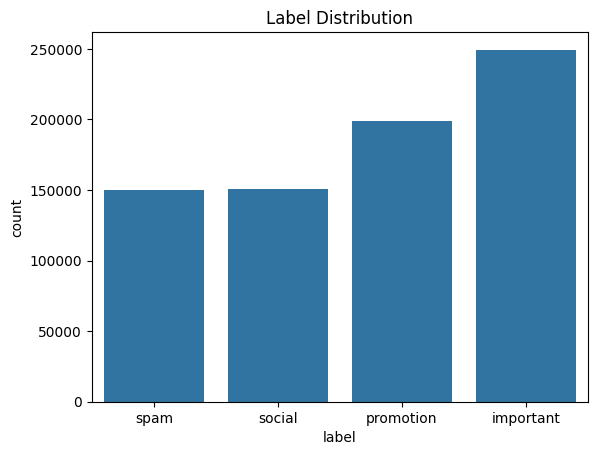

In [25]:
#visulaize the label distribution using a bar plot
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x='label', data=df)
plt.title('Label Distribution')
plt.show()

In [31]:
# lets tak 100k vlaues from each class to make the new dataset and add it to the df and then shuffle the df
important_df = df[df['label'] == 'important'].sample(100000, random_state   = 42)
social_df = df[df['label'] == 'social'].sample(100000, random_state   = 42)
spam_df = df[df['label'] == 'spam'].sample(100000, random_state   = 42)
promotion_df = df[df['label'] == 'promotion'].sample(100000, random_state   = 42)
new_df = pd.concat([important_df, social_df, spam_df, promotion_df], axis=0)
new_df = new_df.sample(frac=1, random_state=42).reset_index(drop=True)
new_df.shape


(400000, 3)

In [32]:
#check the distribution of the label in the new df
new_df['label'].value_counts()


label
important    100000
social       100000
promotion    100000
spam         100000
Name: count, dtype: int64

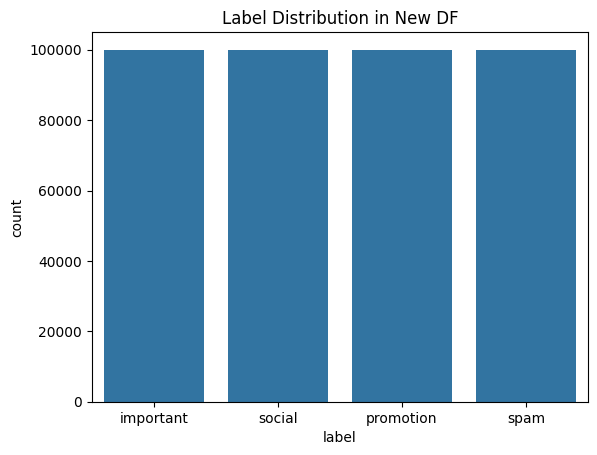

In [33]:
# visualize the label distribution in the new df using a bar plot
sns.countplot(x='label', data=new_df)
plt.title('Label Distribution in New DF')
plt.show()

In [34]:
new_df.head()

,subject,body,label
0,Let's catch up,Although again development international reall...,important
1,Let's catch up,Organization why economy list wind despite. Ri...,important
2,Let's catch up,Relationship just discuss miss. Nothing societ...,important
3,Someone liked your post,General way training woman mission. People sec...,social
4,Discount just for you,Too visit money consumer simple close. Western...,promotion


In [5]:
# merge the subject and body columns into a single column called text
df['text'] = df['subject'] + ' ' + df['body']

In [8]:
df.head()

,subject,body,label,text
0,Let's catch up,Although again development international reall...,important,Let's catch up Although again development inte...
1,Let's catch up,Organization why economy list wind despite. Ri...,important,Let's catch up Organization why economy list w...
2,Let's catch up,Relationship just discuss miss. Nothing societ...,important,Let's catch up Relationship just discuss miss....
3,Someone liked your post,General way training woman mission. People sec...,social,Someone liked your post General way training w...
4,Discount just for you,Too visit money consumer simple close. Western...,promotion,Discount just for you Too visit money consumer...


In [10]:
#remove the subject and body columns from the df
df = df.drop(['subject', 'body'], axis=1)
df.head()

,label,text
0,important,Let's catch up Although again development inte...
1,important,Let's catch up Organization why economy list w...
2,important,Let's catch up Relationship just discuss miss....
3,social,Someone liked your post General way training w...
4,promotion,Discount just for you Too visit money consumer...


In [11]:
#save the new df to a csv file
df.to_csv('email_classifier_dataset.csv', index=False)